In [2]:
from numpy import pi
import pint
from simulation import SimulationConfig, OpticalForceCalculator, DipoleCalculator, SweepRunner
from comsol_data import parse_file
import numpy as np
import matplotlib.pyplot as plt
ureg = pint.UnitRegistry()

/home/uspensky/PyProjects/Mie_SPP_Force/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
wavelen = 640
rad = 100
baseConfig = SimulationConfig(
    wl=wavelen * ureg.nanometer,
    R=rad * ureg.nanometer,
    dist=1 * ureg.nanometer,
    angle=np.deg2rad(25),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle='SiO2',
    amplitude=1,
    show_warnings=False,
    initial_field_type='custom',
    z_beam= 0 * ureg.nanometer,
    w0=450*ureg.nanometer
)

# dips = OpticalForceCalculator(baseConfig).compute()

# R_arr = np.linspace(10, 170, 50) * ureg.nanometer
z_beam_arr = np.linspace(-2*wavelen, wavelen, 50) * ureg.nanometer

res, _, _ = SweepRunner(baseConfig, 'z_beam', z_beam_arr, compute_force=True).run()

Custom field parameters set: w0=450 nanometer, z_beam=0 nanometer













































  0%|          | 0/50 [01:24<?, ?it/s]


[ 2.16951774e-35+7.16028087e-36j  1.76813555e-35+1.47770829e-35j  1.10926504e-35+2.04253394e-35j  2.82213470e-36+2.32751124e-35j -5.98674527e-36+2.28803510e-35j -1.40984255e-35+1.92468421e-35j -2.03583423e-35+1.28371841e-35j -2.38566438e-35+4.51141205e-36j -2.40593178e-35-4.58903723e-36j -2.08879305e-35-1.31982667e-35j -1.47362325e-35-2.01021048e-35j -6.42066403e-36-2.43089657e-35j  2.92893923e-36-2.51913418e-35j  1.20236858e-35-2.25777986e-35j  1.95938077e-35-1.67821190e-35j  2.45659558e-35-8.56494327e-36j  2.62148114e-35+9.67327821e-37j  2.42676137e-35+1.05127812e-35j  1.89466297e-35+1.87528283e-35j  1.09431513e-35+2.45349258e-35j  1.32612427e-36+2.70337601e-35j -8.60235194e-36+2.58683142e-35j -1.74849293e-35+2.11582407e-35j -2.40958307e-35+1.35113202e-35j -2.75107154e-35+3.94332847e-36j -2.72359471e-35-6.25895749e-36j -2.32791474e-35-1.57129357e-35j -1.61509928e-35-2.31294709e-35j -6.79771228e-36-2.74901837e-35j  3.52664709e-36-2.81881900e-35j  1.34307446e-35-2.51127309e-35j  2.1575

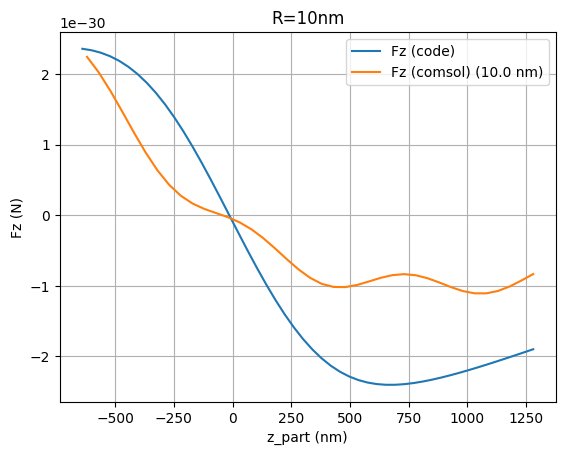

In [8]:
plt.plot(-res.z_beam, res.Fz, label='Fz (code)')
print(res.px)

dataz = parse_file("/home/uspensky/ComsolData/wl640nm_fz_SiO2_r10-100nm_nosubs.csv")

i = rad // 10 - 1
plt.plot(-1E9*dataz[i]["z0 (m)"], dataz[i]["F_z (N)"], label=f"Fz (comsol) ({dataz[i]["% r_part (m)"].iloc[0]*1E9} nm)")

plt.xlabel("z_part (nm)")
plt.ylabel("Fz (N)")
plt.legend()
plt.title(f'R={rad}nm')
plt.grid()
plt.show()

ImportError: cannot import name 'gaussian_beam' from 'fields' (/home/uspensky/PyProjects/Mie_SPP_Force/fields.py)